In [32]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from matplotlib.ticker import FuncFormatter, MaxNLocator
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

sys.path.insert(0, "src")
from profiles import Profile, profiles_to_df
from labels import (
    AGE_GROUP_LABELS,
    INCOME_LABELS,
    COMMUTE_FREQ_LABELS,
    SCHOOL_FREQ_LABELS,
    TELECOMMUTE_DAYS_LABELS,
)

##### Load filtered profiles

In [33]:
with open("artifacts/filtered_profiles.json") as file:
    profiles = [Profile.model_validate(profile_json) for profile_json in json.load(file)]

print(f"Number of profiles: {len(profiles)}")

Number of profiles: 1702


##### Build person-level dataframe

In [34]:
df = profiles_to_df(profiles)
print(f"Rows: {len(df)}, Cols: {len(df.columns)}")

Rows: 1702, Cols: 37


##### Encode and scale features

In [35]:
per_activity_cols = [col for col in df.columns if col.startswith("mean_arrival_") and col != "mean_arrival_minutes"]
numeric_cols = ["household_size", "total_distance", "num_trips", "mean_arrival_minutes", *per_activity_cols]
categorical_cols = [col for col in df.columns if col not in numeric_cols and col != "has_ev"]

encoder = OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value = -1, encoded_missing_value = -1)
encoded = encoder.fit_transform(df[categorical_cols].astype(str))
feature_matrix = np.hstack([encoded, df[numeric_cols].fillna(0).to_numpy()])
scaled_df = StandardScaler().fit_transform(feature_matrix)

print(f"Feature matrix shape: {scaled_df.shape}")

Feature matrix shape: (1702, 36)


##### Remove outliers with iso forest

In [36]:
iso_forest = IsolationForest(contamination = 0.05, random_state = 42)
outlier_mask = iso_forest.fit_predict(scaled_df) == -1
print(f"Outliers removed: {outlier_mask.sum()}")

df = df[~outlier_mask].reset_index(drop = True)
scaled_df = scaled_df[~outlier_mask]

Outliers removed: 86


##### Visualize data with 2d umap

/Users/aryuh/Documents/ev_digital_city/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


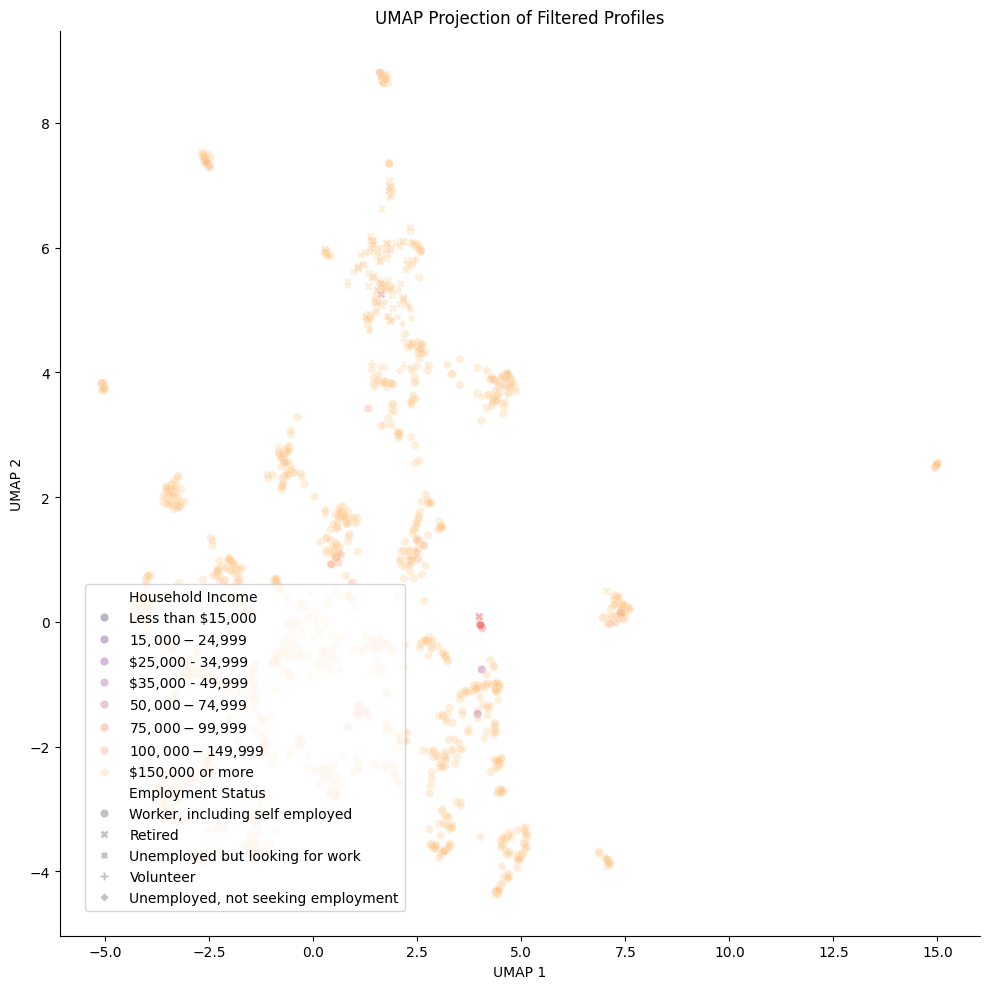

In [37]:
embedding = umap.UMAP(n_components = 2, random_state = 42).fit_transform(scaled_df)
umap_df = pd.DataFrame(embedding, columns = ["UMAP1", "UMAP2"])
umap_df["Household Income"] = df["household_income"].values
umap_df["Employment Status"] = df["employment_status"].values
income_order = [label for label in INCOME_LABELS.values() if label is not None]

plt.figure(figsize = (10, 10))
ax = sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", hue = "Household Income", hue_order = income_order, style = "Employment Status", palette = "magma", alpha = 0.3)
plt.title("UMAP Projection of Filtered Profiles")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
ax.legend(loc = "lower left", bbox_to_anchor = (0.02, 0.02), frameon = True)
sns.despine()
plt.tight_layout()
plt.show()

##### Cluster data with k-means

Selected k = 3 (silhouette = 0.191)


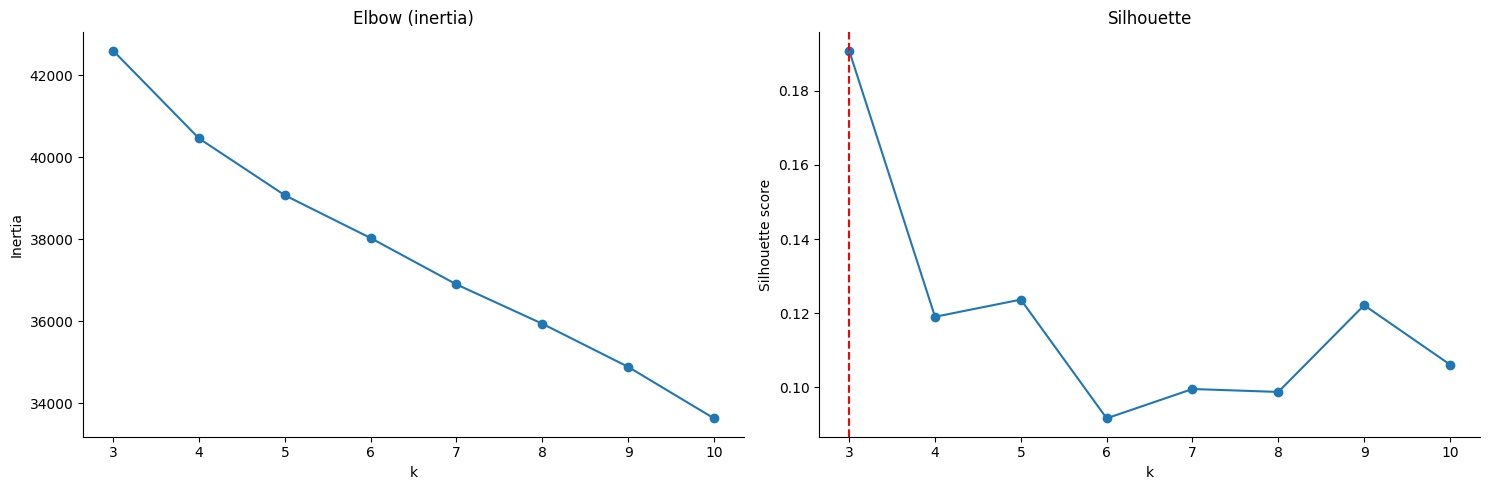

In [38]:
k_range = range(3, 11)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10).fit(scaled_df)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled_df, km.labels_))

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Selected k = {best_k} (silhouette = {max(silhouettes):.3f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
ax1.plot(list(k_range), inertias, marker = "o")
ax1.set_title("Elbow (inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax2.plot(list(k_range), silhouettes, marker = "o")
ax2.axvline(best_k, color = "red", linestyle = "--")
ax2.set_title("Silhouette")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
sns.despine()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(scaled_df)
umap_df["Cluster"] = clusters.astype(str)

##### Visualize clusters

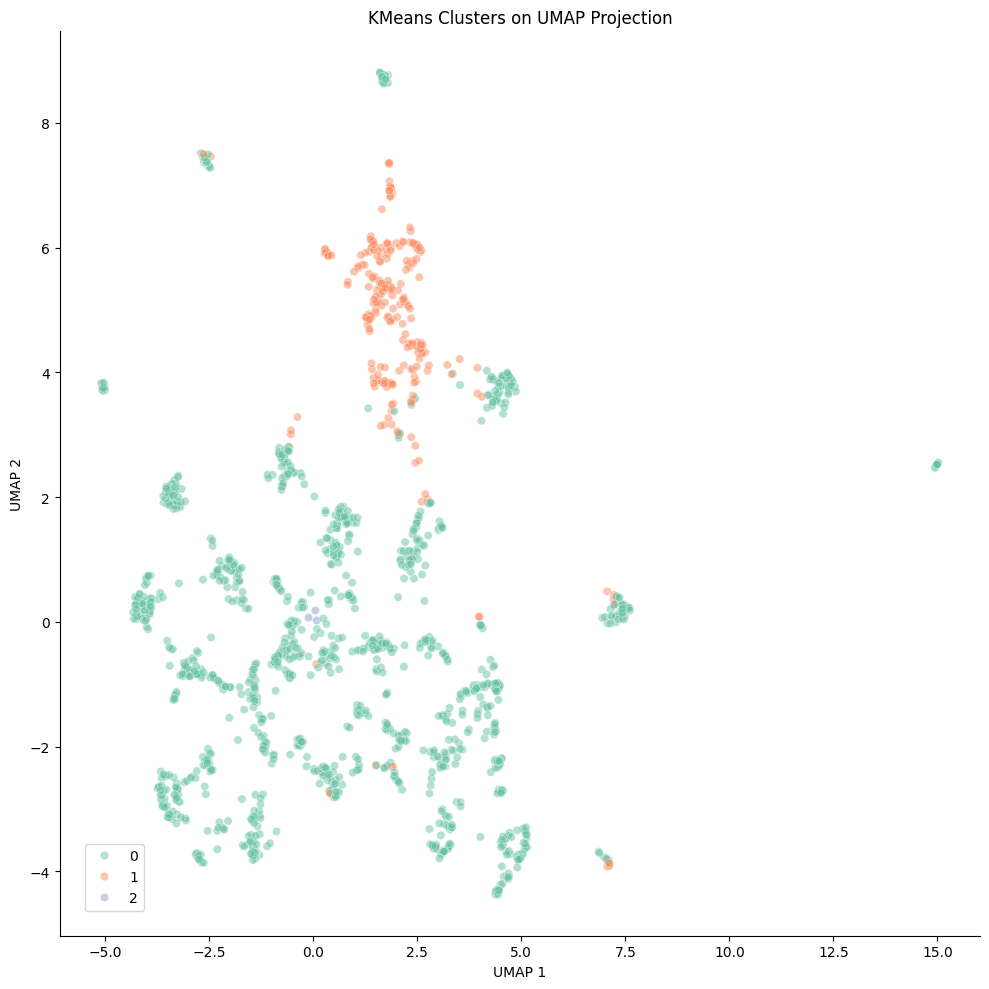

In [39]:
plt.figure(figsize = (10, 10))
ax = sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", hue = "Cluster", palette = "Set2", alpha = 0.5)
plt.title("KMeans Clusters on UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
ax.legend(loc = "lower left", bbox_to_anchor = (0.02, 0.02), frameon = True)
sns.despine()
plt.tight_layout()
plt.show()

##### Group data by cluster

In [40]:
cluster_dfs = [df[clusters == c].reset_index(drop = True) for c in range(best_k)]
for c, cluster_df in enumerate(cluster_dfs):
    print(f"Cluster {c}: {len(cluster_df)} persons")

Cluster 0: 1344 persons
Cluster 1: 269 persons
Cluster 2: 3 persons


##### Graphs for each cluster

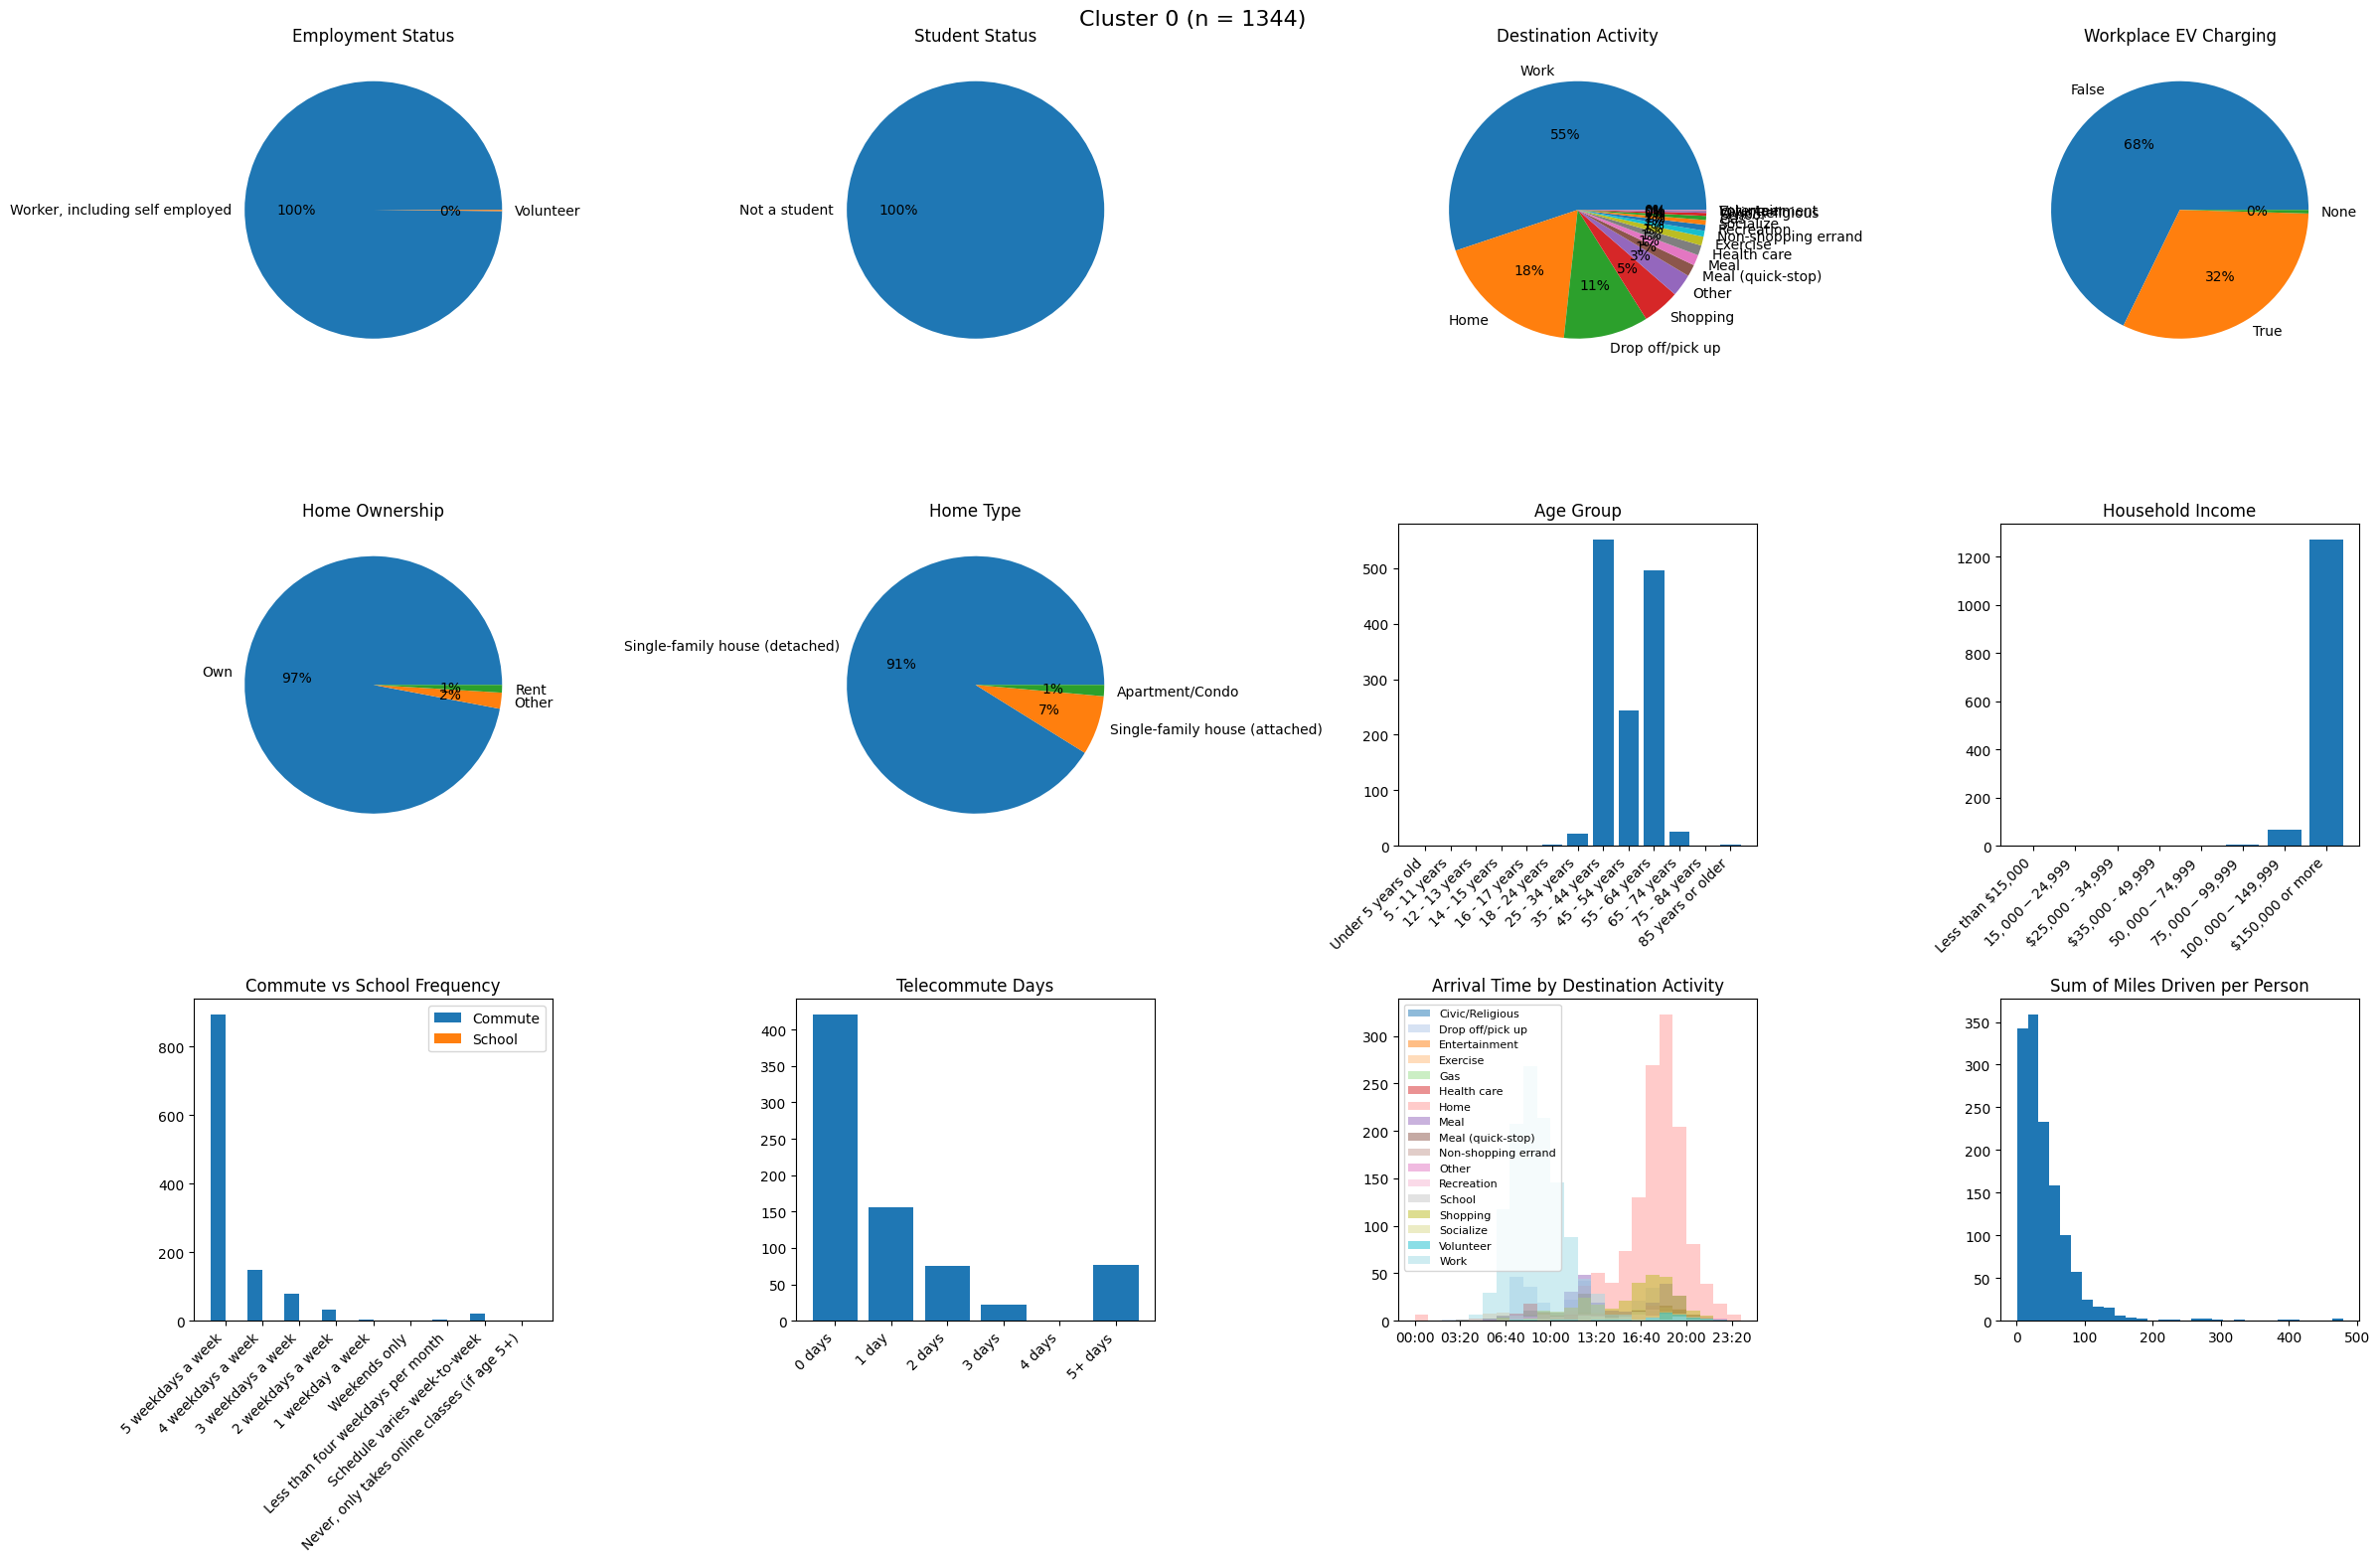

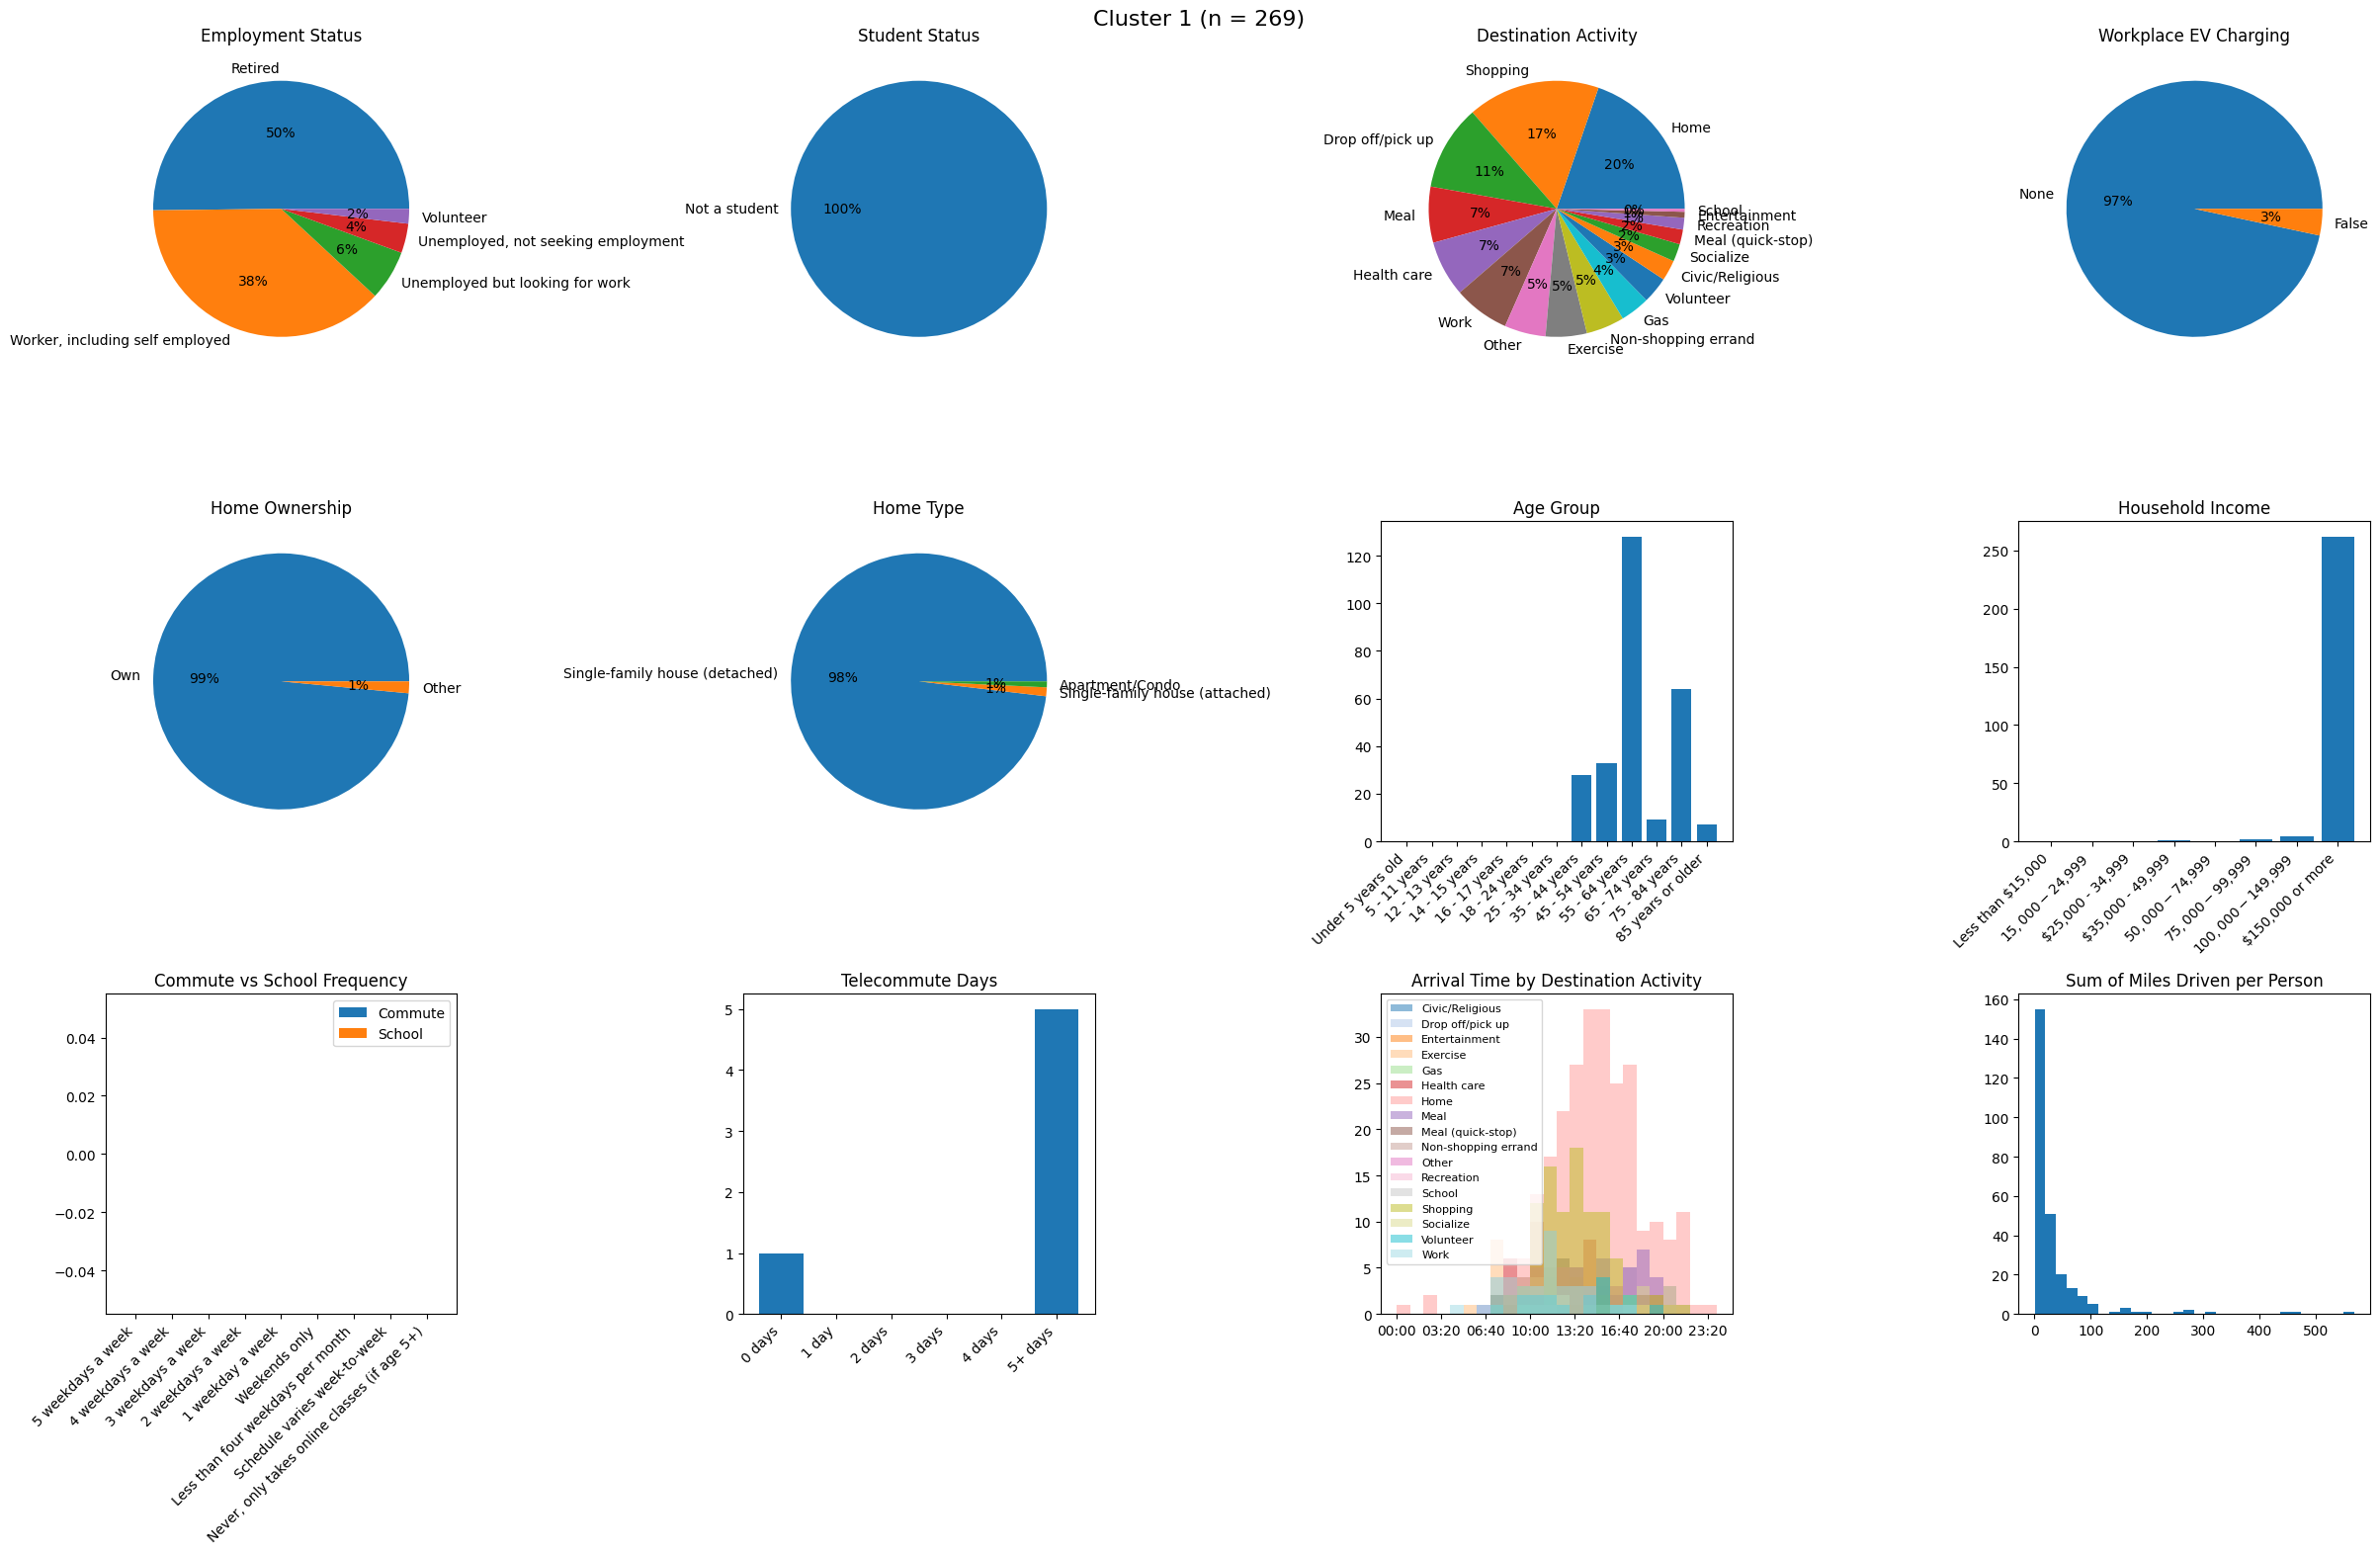

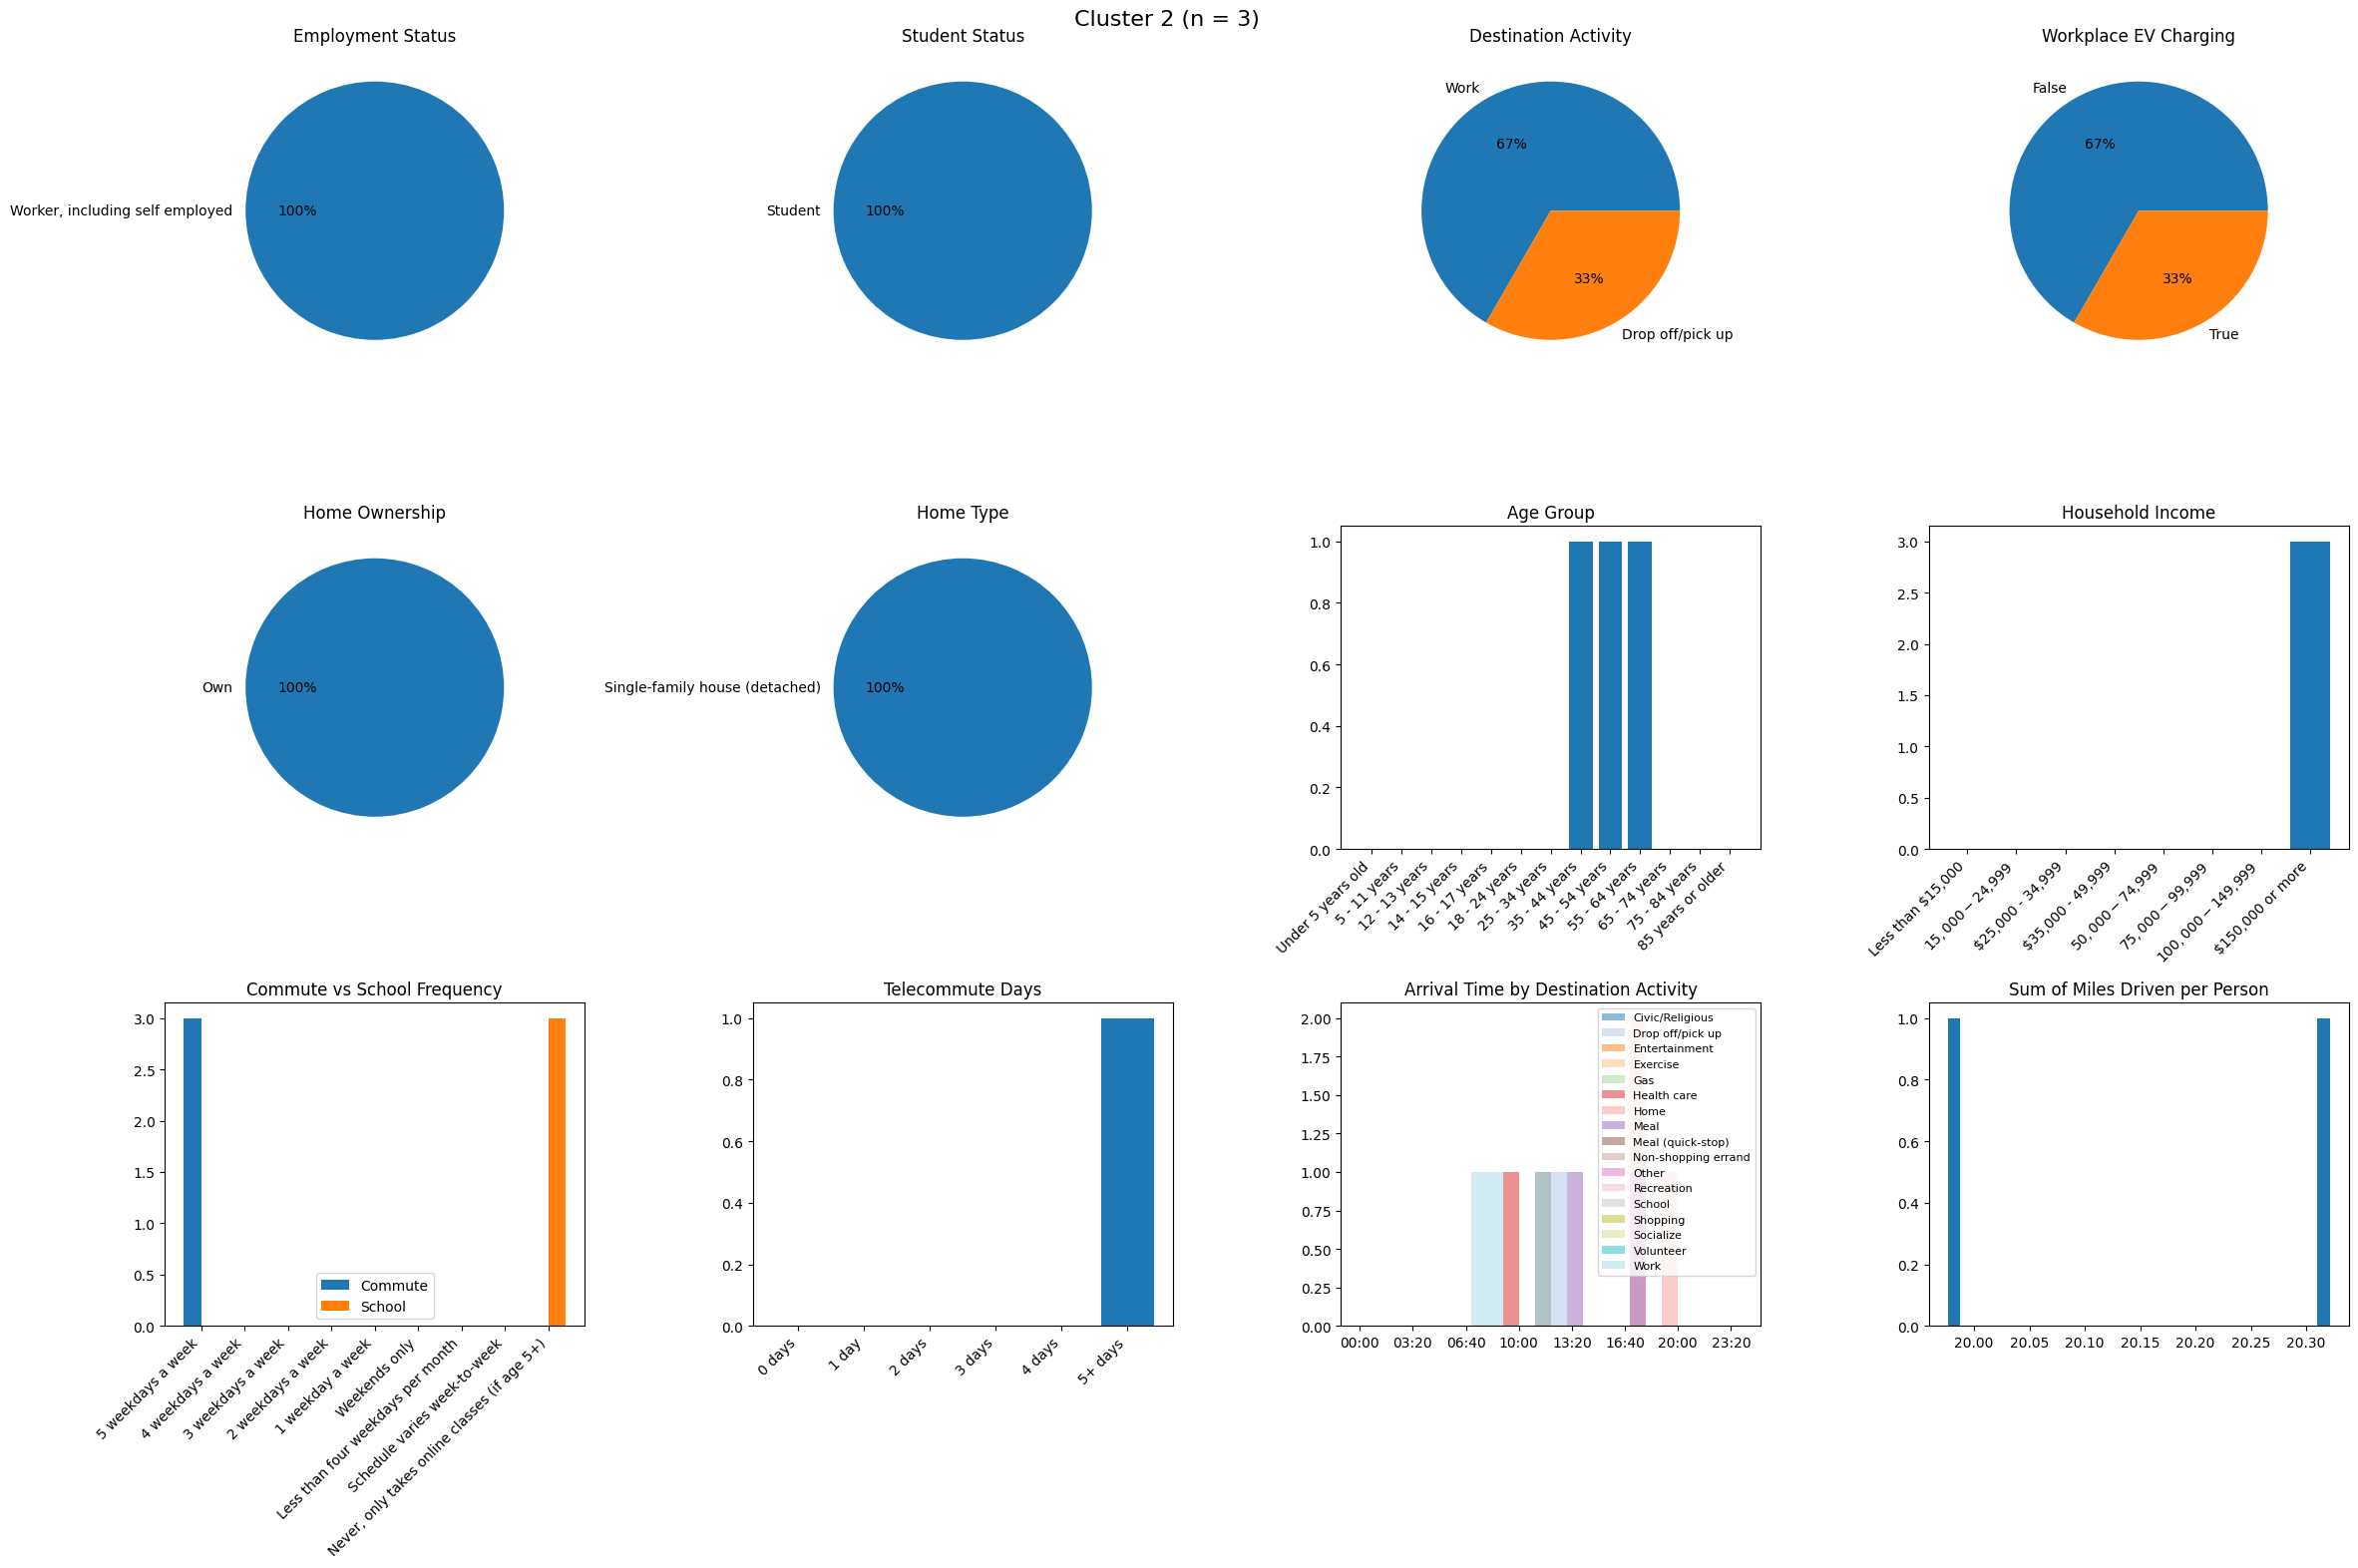

In [41]:
AGE_ORDER = [label for label in AGE_GROUP_LABELS.values() if label is not None]
INCOME_ORDER = [label for label in INCOME_LABELS.values() if label is not None]
COMMUTE_ORDER = [label for label in COMMUTE_FREQ_LABELS.values() if label is not None]
SCHOOL_ORDER = [label for label in SCHOOL_FREQ_LABELS.values() if label is not None]
FREQ_ORDER = list(dict.fromkeys(COMMUTE_ORDER + SCHOOL_ORDER))
TELECOMMUTE_ORDER = [label for label in TELECOMMUTE_DAYS_LABELS.values() if label is not None]


def pie(ax, series: pd.Series, title: str) -> None:
    counts = series.fillna("None").astype(str).value_counts()
    ax.pie(counts, labels = counts.index, autopct = "%1.0f%%")
    ax.set_title(title)


def ordered_bar(ax, series: pd.Series, order: list[str], title: str, rotation: int = 45) -> None:
    counts = series.fillna("None").astype(str).value_counts().reindex(order, fill_value = 0)
    ax.bar(np.arange(len(order)), counts.values)
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(order, rotation = rotation, ha = "right")
    ax.set_title(title)


def grouped_freq_bar(ax, cluster_df: pd.DataFrame, title: str) -> None:
    commute_counts = cluster_df["commute_freq"].fillna("None").astype(str).value_counts().reindex(FREQ_ORDER, fill_value = 0)
    school_counts = cluster_df["school_freq"].fillna("None").astype(str).value_counts().reindex(FREQ_ORDER, fill_value = 0)
    x = np.arange(len(FREQ_ORDER))
    ax.bar(x - 0.2, commute_counts.values, width = 0.4, label = "Commute")
    ax.bar(x + 0.2, school_counts.values, width = 0.4, label = "School")
    ax.set_xticks(x)
    ax.set_xticklabels(FREQ_ORDER, rotation = 45, ha = "right")
    ax.set_title(title)
    ax.legend()


def arrival_time_by_activity_hist(ax, cluster_df: pd.DataFrame, title: str) -> None:
    per_activity_cols = sorted(col for col in cluster_df.columns if col.startswith("mean_arrival_") and col != "mean_arrival_minutes")
    cmap = plt.colormaps["tab20"].resampled(max(len(per_activity_cols), 1))
    bins = np.linspace(0, 1440, 25)
    for i, col in enumerate(per_activity_cols):
        values = cluster_df[col].dropna()
        activity = col.removeprefix("mean_arrival_")
        ax.hist(values, bins = bins, alpha = 0.5, label = activity, color = cmap(i))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda m, _: f"{int(m) // 60:02d}:{int(m) % 60:02d}"))
    ax.set_title(title)
    ax.legend(fontsize = 8)


def graph_cluster(cluster_df: pd.DataFrame, title_prefix: str) -> None:
    fig, axes = plt.subplots(3, 4, figsize = (24, 16))
    fig.suptitle(f"{title_prefix} (n = {len(cluster_df)})", fontsize = 16)

    pie(axes[0, 0], cluster_df["employment_status"], "Employment Status")
    pie(axes[0, 1], cluster_df["student_status"], "Student Status")
    pie(axes[0, 2], cluster_df["dominant_dest_activity"], "Destination Activity")
    pie(axes[0, 3], cluster_df["workplace_ev_charging"], "Workplace EV Charging")

    pie(axes[1, 0], cluster_df["home_ownership"], "Home Ownership")
    pie(axes[1, 1], cluster_df["home_type"], "Home Type")
    ordered_bar(axes[1, 2], cluster_df["age_group"], AGE_ORDER, "Age Group")
    ordered_bar(axes[1, 3], cluster_df["household_income"], INCOME_ORDER, "Household Income")

    grouped_freq_bar(axes[2, 0], cluster_df, "Commute vs School Frequency")
    ordered_bar(axes[2, 1], cluster_df["telecommute_days"], TELECOMMUTE_ORDER, "Telecommute Days")
    arrival_time_by_activity_hist(axes[2, 2], cluster_df, "Arrival Time by Destination Activity")
    distance_cutoff = cluster_df["total_distance"].quantile(0.99)
    axes[2, 3].hist(cluster_df.loc[cluster_df["total_distance"] <= distance_cutoff, "total_distance"], bins = 30)
    axes[2, 3].set_title("Sum of Miles Driven per Person")

    plt.tight_layout()
    plt.show()


for cluster_id, cluster_df in enumerate(cluster_dfs):
    graph_cluster(cluster_df, f"Cluster {cluster_id}")